In [38]:
import argparse
import torch
import torch.nn as nn
import os
import pandas as pd
import yaml
from copy import deepcopy
import numpy as np
from tqdm import tqdm
from scipy import stats
from sklearn import metrics
from typing import List
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault
from src.model.data import DeepBurstDataset
from src.model.net import  DeepBurst
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from src.model.constants import get_config
from matplotlib import rcParams, rcParamsDefault
import matplotlib.colors as mcolors


torch.autograd.set_detect_anomaly(True)


EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}


In [39]:
rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 6 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'black',   
        'legend.edgecolor': 'black',
        'legend.labelcolor': 'black',  # 设置图例标签字体颜色（在新版matplotlib中支持）
        'axes.edgecolor': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'axes.titlecolor': 'black',
        'axes.labelcolor': 'black',

        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        'text.color': 'black',  # 全局文字颜色

        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )


# COLOR_MAP = {'H3K4me1':'#A28F19','H3K4me3':'#7FA5D0','H3K9me3':'#FDE4A4','H3K27ac':'#F5B6AC','H3K27me3':'#7CA68B','H3K36me3':'#80448A','H3K9ac':'#C7886D'}
COLOR_MAP = {'H3K4me1':'#BB72AC','H3K4me3':'#56B4E6','H3K9me3':'#7CC9C1','H3K27ac':'#EC6D5D','H3K27me3':'#F4DE28','H3K36me3':'#88C463','H3K9ac':'#3D60AC'}

COLORS = ['#39729C', "#D8B66F"]
palette=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=60)


In [40]:
targets=['bf_label','bs_label']
with open('benchmarks/revised_v2/reviewer4/results/bs_bf_cellcycle_indicators.csv','w') as w:
    line = ['eid','fold','auc','target','phase','phase_origin','infer_method']
    w.write(','.join(line) + '\n')
    for eid in ["E116"]:    
        for phase in ['G1','S','G2M']:  
                for phase_origin in ['origin', 'deepcycle']:      
                     for infer_method in ['txburst', 'deeptx']:
                        for fold in [0,1,2,3]:
                            checkpoints = f"benchmarks/revised_v2/reviewer4/checkpoints/{eid}.{phase}.{phase_origin}.{infer_method}.fold{fold}.bs_bf_para.model.pt"
                            ckpt = torch.load(checkpoints,map_location=DEVICE)
                            for target in targets:
                                auc = ckpt[f"{target}_val_auc"]
                                line = [eid,str(fold),str(auc),target,phase,phase_origin,infer_method]
                                w.write(','.join(line) + '\n')

data = pd.read_csv('benchmarks/revised_v2/reviewer4/results/bs_bf_cellcycle_indicators.csv')
data

,eid,fold,auc,target,phase,phase_origin,infer_method
0,E116,0,89.082988,bf_label,G1,origin,txburst
1,E116,0,90.811893,bs_label,G1,origin,txburst
2,E116,1,90.277286,bf_label,G1,origin,txburst
3,E116,1,91.877627,bs_label,G1,origin,txburst
4,E116,2,89.394494,bf_label,G1,origin,txburst
...,...,...,...,...,...,...,...
91,E116,1,62.160338,bs_label,G2M,deepcycle,deeptx
92,E116,2,94.682652,bf_label,G2M,deepcycle,deeptx
93,E116,2,60.444341,bs_label,G2M,deepcycle,deeptx
94,E116,3,94.153838,bf_label,G2M,deepcycle,deeptx


# origin txburst

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/182449534.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx].legend().remove()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/182449534.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[idx].set_xticklabels(xtick_labels,rotation=0,)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/182449534.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx].legend().remove()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/182449534.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_t

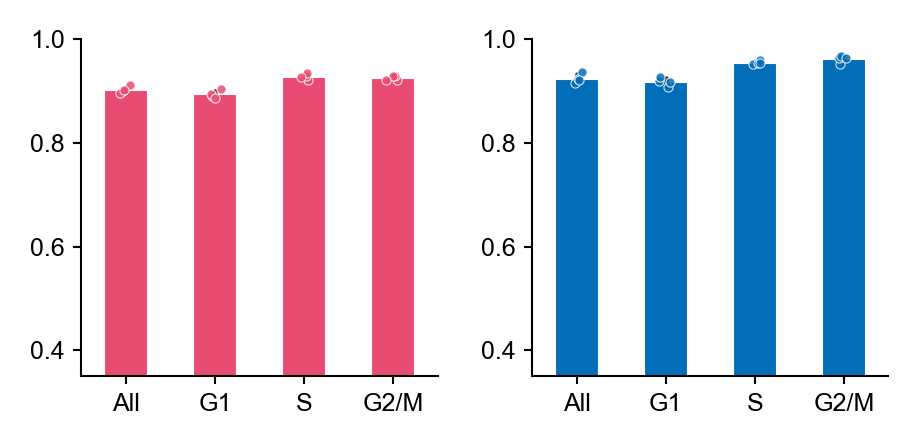

In [41]:
PHASE_ORIGIN = 'origin'
INFER_METHOD = 'txburst'
targets=['bf_label','bs_label']
data = pd.read_csv('benchmarks/revised_v2/reviewer4/results/bs_bf_cellcycle_indicators.csv')
sub_data = data[(data['phase_origin']==PHASE_ORIGIN) & (data['infer_method']==INFER_METHOD)].drop(columns=['phase_origin','infer_method'])

data_non_cellcycle = pd.read_csv('extra/results/bs_bf_para_indicators.csv')
data_non_cellcycle['phase'] = 'All'
data_non_cellcycle = data_non_cellcycle[data_non_cellcycle['eid']=='E116']

sub_data = pd.concat([sub_data, data_non_cellcycle], ignore_index=True)

sub_data['auc'] = sub_data['auc']/100
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(8/2.54, 4/2.54))
order = pd.Index(['All','G1','S','G2M',],name='marks')
xtick_labels = ['All','G1','S','G2/M',]
hue_order = pd.Index(["bf_label","bs_label"],name='target')

palette = ['#E94C72','#036EB8']


for idx, target in enumerate(targets):
    sns.barplot(data=sub_data[sub_data['target']==target],
                x='phase',
                y='auc',
                ax=ax[idx],order=order,
                color=palette[idx],width=0.5,alpha=1.0,saturation=1,linewidth=0.5
                )
    sns.stripplot(
        data=sub_data[sub_data['target']==target],
        x="phase",
        y="auc",
        order=order,
        color=palette[idx],
        dodge=True,
        jitter=0.08,
        size=2.2,
        alpha=0.85,
        linewidth=0.25,
        edgecolor="white",
        ax=ax[idx],
        legend=False,
    )
        # Show the plot
    ax[idx].set_ylabel("")
    ax[idx].set_xlabel("")
    ax[idx].set_ylim(ymin=0.35, ymax=1.0)
    ax[idx].legend().remove()
    ax[idx].set_xticklabels(xtick_labels,rotation=0,)

plt.tight_layout()
plt.savefig(f"benchmarks/revised_v2/reviewer4/figures/cellcycle_model_performance_{PHASE_ORIGIN}_{INFER_METHOD}.pdf", format='pdf', bbox_inches='tight')
plt.show()


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/1805169554.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx].legend().remove()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/1805169554.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx].legend().remove()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/1805169554.py:138: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


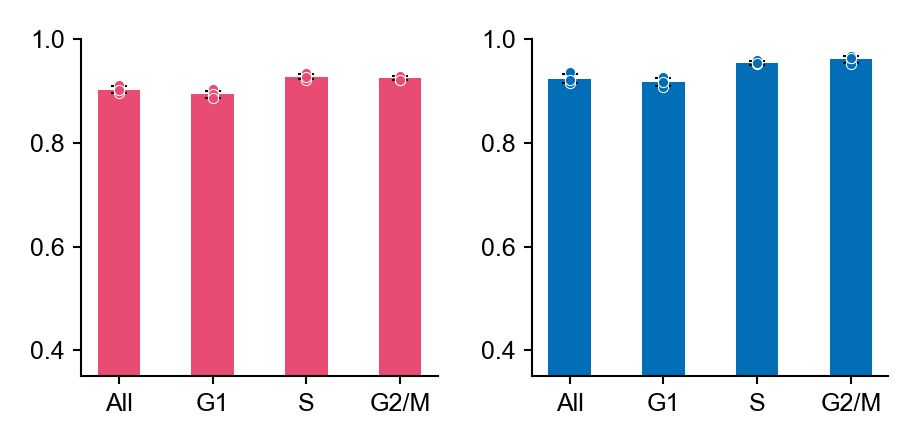

In [42]:
# =========================
# config
# =========================
PHASE_ORIGIN = 'origin'
INFER_METHOD = 'txburst'
targets = ['bf_label','bs_label']

# =========================
# data load
# =========================
# data = pd.read_csv('benchmarks/revised_v2/reviewer4/results/bs_bf_cellcycle_indicators.csv')

sub_data = data[
    (data['phase_origin'] == PHASE_ORIGIN) &
    (data['infer_method'] == INFER_METHOD)
].drop(columns=['phase_origin','infer_method'])

data_non_cellcycle = pd.read_csv('extra/results/bs_bf_para_indicators.csv')
data_non_cellcycle['phase'] = 'All'
data_non_cellcycle = data_non_cellcycle[data_non_cellcycle['eid'] == 'E116']

sub_data = pd.concat([sub_data, data_non_cellcycle], ignore_index=True)
sub_data['auc'] = sub_data['auc'] / 100


# =========================
# plot setup
# =========================
fig, ax = plt.subplots(
    1, 2,
    constrained_layout=True,
    figsize=(8/2.54, 4/2.54)
)

order = ['All','G1','S','G2M']
xtick_labels = ['All','G1','S','G2/M']

x_base = np.arange(len(order))

# =========================================================
# GEOMETRY CONTROL (phase spacing system)
# =========================================================
hue_spacing = 0
bar_width = 0.45
offsets = np.linspace(-hue_spacing/2, hue_spacing/2, len(targets))

palette = {
    'bf_label': '#E94C72',
    'bs_label': '#036EB8'
}


# =========================================================
# MAIN LOOP
# =========================================================
for idx, target in enumerate(targets):

    df = sub_data[sub_data['target'] == target]

    summary = df.groupby(['phase'])['auc'].agg(['mean','std']).reset_index()

    # -------------------------
    # BAR + ERRORBAR
    # -------------------------
    means = np.array([summary[summary['phase'] == p]['mean'].values[0] for p in order])
    stds  = np.array([summary[summary['phase'] == p]['std'].values[0] for p in order])

    xpos = x_base + offsets[idx]

    ax[idx].bar(
        xpos,
        means,
        width=bar_width,
        color=palette[target],
        alpha=1.0,
        linewidth=0.0,
        edgecolor='none'
    )

    ax[idx].errorbar(
        xpos,
        means,
        yerr=stds,
        fmt='none',
        ecolor='black',
        elinewidth=0.5,
        capsize=2,
        capthick=0.5,
        zorder=2
    )

    # -------------------------
    # DOTPLOT (manual scatter)
    # -------------------------
    for p_idx, phase in enumerate(order):

        sub_raw = df[df['phase'] == phase]

        # jitter-free deterministic scatter
        x = np.full(len(sub_raw), x_base[p_idx]) + offsets[idx]

        ax[idx].scatter(
            x,
            sub_raw['auc'].values,
            s=6,
            color=palette[target],
            alpha=1.0,
            edgecolor="white",
            linewidth=0.25,
            zorder=3
        )

    # -------------------------
    # formatting
    # -------------------------
    ax[idx].set_ylabel("")
    ax[idx].set_xlabel("")
    ax[idx].set_ylim(0.35, 1.0)
    ax[idx].set_xticks(x_base)
    ax[idx].set_xticklabels(xtick_labels, rotation=0)

    ax[idx].legend().remove()


# =========================
# legend
# =========================
legend_patches = [
    mpatches.Patch(color='#E94C72', label='BF'),
    mpatches.Patch(color='#036EB8', label='BS'),
]

fig.legend(handles=legend_patches, loc='upper center', ncol=2, frameon=False).remove()

# =========================
# save
# =========================
plt.tight_layout()

plt.savefig(
    f"benchmarks/revised_v2/reviewer4/figures/cellcycle_model_performance_{PHASE_ORIGIN}_{INFER_METHOD}.pdf",
    format='pdf',
    bbox_inches='tight'
)

plt.show()

# deepcycle txburst

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/3226687080.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx].legend().remove()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/3226687080.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[idx].set_xticklabels(xtick_labels,rotation=0,)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/3226687080.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx].legend().remove()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/3226687080.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after s

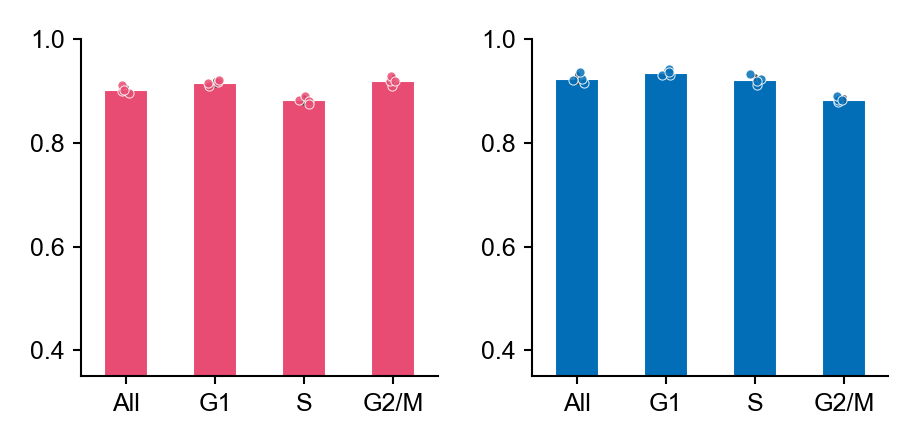

In [43]:
PHASE_ORIGIN = 'deepcycle'
INFER_METHOD = 'txburst'
sub_data = data[(data['phase_origin']==PHASE_ORIGIN) & (data['infer_method']==INFER_METHOD)].drop(columns=['phase_origin','infer_method'])

data_non_cellcycle = pd.read_csv('extra/results/bs_bf_para_indicators.csv')
data_non_cellcycle['phase'] = 'All'
data_non_cellcycle = data_non_cellcycle[data_non_cellcycle['eid']=='E116']

sub_data = pd.concat([sub_data, data_non_cellcycle], ignore_index=True)

sub_data['auc'] = sub_data['auc']/100
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(8/2.54, 4/2.54))
order = pd.Index(['All','G1','S','G2M',],name='marks')
xtick_labels = ['All','G1','S','G2/M',]
hue_order = pd.Index(["bf_label","bs_label"],name='target')

palette = ['#E94C72','#036EB8']


for idx, target in enumerate(targets):
    sns.barplot(data=sub_data[sub_data['target']==target],
                x='phase',
                y='auc',
                ax=ax[idx],order=order,
                color=palette[idx],width=0.5,alpha=1.0,saturation=1,linewidth=0.5
                )
    sns.stripplot(
        data=sub_data[sub_data['target']==target],
        x="phase",
        y="auc",
        order=order,
        color=palette[idx],
        dodge=True,
        jitter=0.08,
        size=2.2,
        alpha=0.85,
        linewidth=0.25,
        edgecolor="white",
        ax=ax[idx],
        legend=False,
    )
        # Show the plot
    ax[idx].set_ylabel("")
    ax[idx].set_xlabel("")
    ax[idx].set_ylim(ymin=0.35, ymax=1.0)
    ax[idx].legend().remove()
    ax[idx].set_xticklabels(xtick_labels,rotation=0,)

plt.tight_layout()
plt.savefig(f"benchmarks/revised_v2/reviewer4/figures/cellcycle_model_performance_{PHASE_ORIGIN}_{INFER_METHOD}.pdf", format='pdf', bbox_inches='tight')
plt.show()

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/4176393768.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx].legend().remove()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/4176393768.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx].legend().remove()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/4176393768.py:138: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


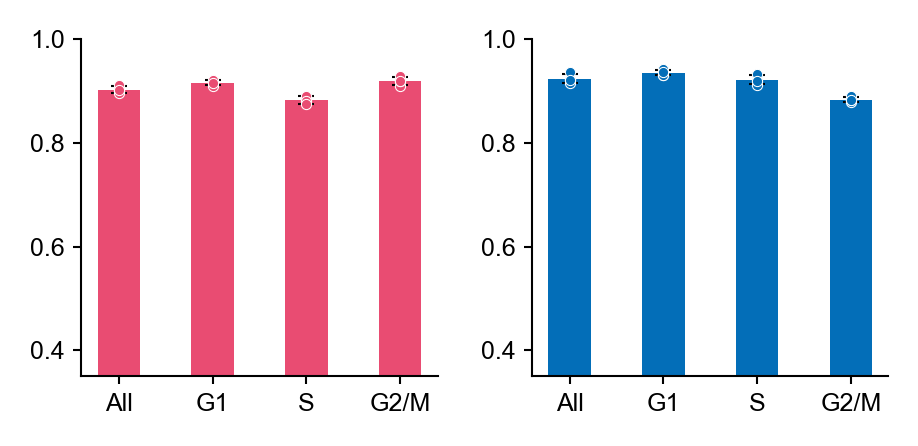

In [44]:
# =========================
# config
# =========================
PHASE_ORIGIN = 'deepcycle'
INFER_METHOD = 'txburst'
targets = ['bf_label','bs_label']

# =========================
# data load
# =========================
# data = pd.read_csv('benchmarks/revised_v2/reviewer4/results/bs_bf_cellcycle_indicators.csv')

sub_data = data[
    (data['phase_origin'] == PHASE_ORIGIN) &
    (data['infer_method'] == INFER_METHOD)
].drop(columns=['phase_origin','infer_method'])

data_non_cellcycle = pd.read_csv('extra/results/bs_bf_para_indicators.csv')
data_non_cellcycle['phase'] = 'All'
data_non_cellcycle = data_non_cellcycle[data_non_cellcycle['eid'] == 'E116']

sub_data = pd.concat([sub_data, data_non_cellcycle], ignore_index=True)
sub_data['auc'] = sub_data['auc'] / 100


# =========================
# plot setup
# =========================
fig, ax = plt.subplots(
    1, 2,
    constrained_layout=True,
    figsize=(8/2.54, 4/2.54)
)

order = ['All','G1','S','G2M']
xtick_labels = ['All','G1','S','G2/M']

x_base = np.arange(len(order))

# =========================================================
# GEOMETRY CONTROL (phase spacing system)
# =========================================================
hue_spacing = 0
bar_width = 0.45
offsets = np.linspace(-hue_spacing/2, hue_spacing/2, len(targets))

palette = {
    'bf_label': '#E94C72',
    'bs_label': '#036EB8'
}


# =========================================================
# MAIN LOOP
# =========================================================
for idx, target in enumerate(targets):

    df = sub_data[sub_data['target'] == target]

    summary = df.groupby(['phase'])['auc'].agg(['mean','std']).reset_index()

    # -------------------------
    # BAR + ERRORBAR
    # -------------------------
    means = np.array([summary[summary['phase'] == p]['mean'].values[0] for p in order])
    stds  = np.array([summary[summary['phase'] == p]['std'].values[0] for p in order])

    xpos = x_base + offsets[idx]

    ax[idx].bar(
        xpos,
        means,
        width=bar_width,
        color=palette[target],
        alpha=1.0,
        linewidth=0.0,
        edgecolor='none'
    )

    ax[idx].errorbar(
        xpos,
        means,
        yerr=stds,
        fmt='none',
        ecolor='black',
        elinewidth=0.5,
        capsize=2,
        capthick=0.5,
        zorder=2
    )

    # -------------------------
    # DOTPLOT (manual scatter)
    # -------------------------
    for p_idx, phase in enumerate(order):

        sub_raw = df[df['phase'] == phase]

        # jitter-free deterministic scatter
        x = np.full(len(sub_raw), x_base[p_idx]) + offsets[idx]

        ax[idx].scatter(
            x,
            sub_raw['auc'].values,
            s=6,
            color=palette[target],
            alpha=1.0,
            edgecolor="white",
            linewidth=0.25,
            zorder=3
        )

    # -------------------------
    # formatting
    # -------------------------
    ax[idx].set_ylabel("")
    ax[idx].set_xlabel("")
    ax[idx].set_ylim(0.35, 1.0)
    ax[idx].set_xticks(x_base)
    ax[idx].set_xticklabels(xtick_labels, rotation=0)

    ax[idx].legend().remove()


# =========================
# legend
# =========================
legend_patches = [
    mpatches.Patch(color='#E94C72', label='BF'),
    mpatches.Patch(color='#036EB8', label='BS'),
]

fig.legend(handles=legend_patches, loc='upper center', ncol=2, frameon=False).remove()

# =========================
# save
# =========================
plt.tight_layout()

plt.savefig(
    f"benchmarks/revised_v2/reviewer4/figures/cellcycle_model_performance_{PHASE_ORIGIN}_{INFER_METHOD}.pdf",
    format='pdf',
    bbox_inches='tight'
)

plt.show()

# origin deeptx

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/3358534275.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx].legend().remove()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/3358534275.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[idx].set_xticklabels(xtick_labels,rotation=0,)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/3358534275.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx].legend().remove()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/3358534275.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after s

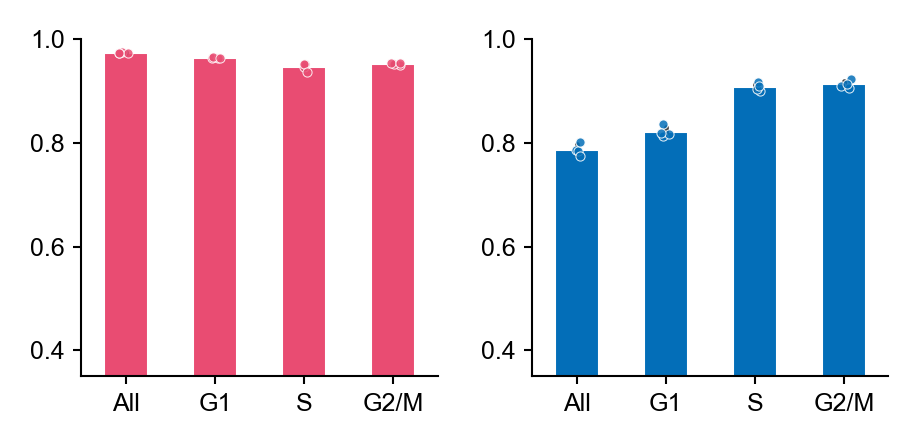

In [45]:
PHASE_ORIGIN = 'origin'
INFER_METHOD = 'deeptx'
sub_data = data[(data['phase_origin']==PHASE_ORIGIN) & (data['infer_method']==INFER_METHOD)].drop(columns=['phase_origin','infer_method'])

data_non_cellcycle = pd.read_csv('extra/results/bs_bf_deeptx_indicators.csv')
data_non_cellcycle['phase'] = 'All'
data_non_cellcycle = data_non_cellcycle[data_non_cellcycle['eid']=='E116']

sub_data = pd.concat([sub_data, data_non_cellcycle], ignore_index=True)

sub_data['auc'] = sub_data['auc']/100
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(8/2.54, 4/2.54))
order = pd.Index(['All','G1','S','G2M',],name='marks')
xtick_labels = ['All','G1','S','G2/M',]
hue_order = pd.Index(["bf_label","bs_label"],name='target')

palette = ['#E94C72','#036EB8']


for idx, target in enumerate(targets):
    sns.barplot(data=sub_data[sub_data['target']==target],
                x='phase',
                y='auc',
                ax=ax[idx],order=order,
                color=palette[idx],width=0.5,alpha=1.0,saturation=1,linewidth=0.5
                )
    sns.stripplot(
        data=sub_data[sub_data['target']==target],
        x="phase",
        y="auc",
        order=order,
        color=palette[idx],
        dodge=True,
        jitter=0.08,
        size=2.2,
        alpha=0.85,
        linewidth=0.25,
        edgecolor="white",
        ax=ax[idx],
        legend=False,
    )

        # Show the plot
    ax[idx].set_ylabel("")
    ax[idx].set_xlabel("")
    ax[idx].set_ylim(ymin=0.35, ymax=1.0)
    ax[idx].legend().remove()
    ax[idx].set_xticklabels(xtick_labels,rotation=0,)

plt.tight_layout()
plt.savefig(f"benchmarks/revised_v2/reviewer4/figures/cellcycle_model_performance_{PHASE_ORIGIN}_{INFER_METHOD}.pdf", format='pdf', bbox_inches='tight')
plt.show()

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/3848054062.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx].legend().remove()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/3848054062.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx].legend().remove()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/3848054062.py:138: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


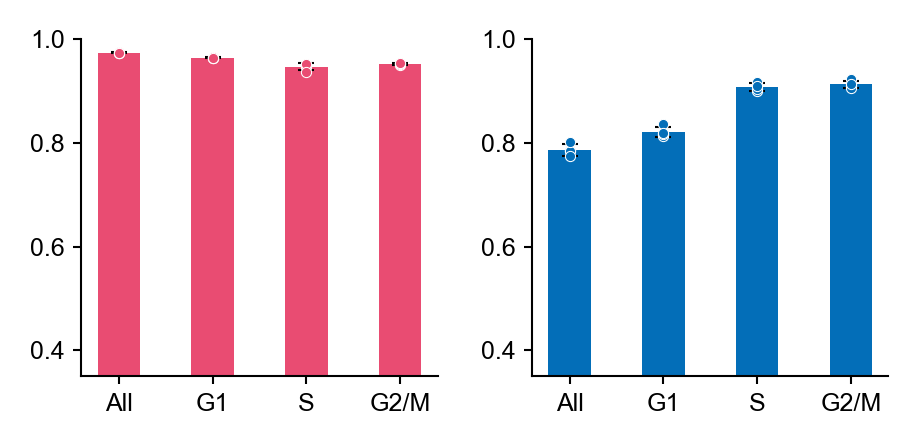

In [46]:
# =========================
# config
# =========================
PHASE_ORIGIN = 'origin'
INFER_METHOD = 'deeptx'
targets = ['bf_label','bs_label']

# =========================
# data load
# =========================
# data = pd.read_csv('benchmarks/revised_v2/reviewer4/results/bs_bf_cellcycle_indicators.csv')

sub_data = data[
    (data['phase_origin'] == PHASE_ORIGIN) &
    (data['infer_method'] == INFER_METHOD)
].drop(columns=['phase_origin','infer_method'])

data_non_cellcycle = pd.read_csv('extra/results/bs_bf_deeptx_indicators.csv')
data_non_cellcycle['phase'] = 'All'
data_non_cellcycle = data_non_cellcycle[data_non_cellcycle['eid'] == 'E116']

sub_data = pd.concat([sub_data, data_non_cellcycle], ignore_index=True)
sub_data['auc'] = sub_data['auc'] / 100


# =========================
# plot setup
# =========================
fig, ax = plt.subplots(
    1, 2,
    constrained_layout=True,
    figsize=(8/2.54, 4/2.54)
)

order = ['All','G1','S','G2M']
xtick_labels = ['All','G1','S','G2/M']

x_base = np.arange(len(order))

# =========================================================
# GEOMETRY CONTROL (phase spacing system)
# =========================================================
hue_spacing = 0
bar_width = 0.45
offsets = np.linspace(-hue_spacing/2, hue_spacing/2, len(targets))

palette = {
    'bf_label': '#E94C72',
    'bs_label': '#036EB8'
}


# =========================================================
# MAIN LOOP
# =========================================================
for idx, target in enumerate(targets):

    df = sub_data[sub_data['target'] == target]

    summary = df.groupby(['phase'])['auc'].agg(['mean','std']).reset_index()

    # -------------------------
    # BAR + ERRORBAR
    # -------------------------
    means = np.array([summary[summary['phase'] == p]['mean'].values[0] for p in order])
    stds  = np.array([summary[summary['phase'] == p]['std'].values[0] for p in order])

    xpos = x_base + offsets[idx]

    ax[idx].bar(
        xpos,
        means,
        width=bar_width,
        color=palette[target],
        alpha=1.0,
        linewidth=0.0,
        edgecolor='none'
    )

    ax[idx].errorbar(
        xpos,
        means,
        yerr=stds,
        fmt='none',
        ecolor='black',
        elinewidth=0.5,
        capsize=2,
        capthick=0.5,
        zorder=2
    )

    # -------------------------
    # DOTPLOT (manual scatter)
    # -------------------------
    for p_idx, phase in enumerate(order):

        sub_raw = df[df['phase'] == phase]

        # jitter-free deterministic scatter
        x = np.full(len(sub_raw), x_base[p_idx]) + offsets[idx]

        ax[idx].scatter(
            x,
            sub_raw['auc'].values,
            s=6,
            color=palette[target],
            alpha=1.0,
            edgecolor="white",
            linewidth=0.25,
            zorder=3
        )

    # -------------------------
    # formatting
    # -------------------------
    ax[idx].set_ylabel("")
    ax[idx].set_xlabel("")
    ax[idx].set_ylim(0.35, 1.0)
    ax[idx].set_xticks(x_base)
    ax[idx].set_xticklabels(xtick_labels, rotation=0)

    ax[idx].legend().remove()


# =========================
# legend
# =========================
legend_patches = [
    mpatches.Patch(color='#E94C72', label='BF'),
    mpatches.Patch(color='#036EB8', label='BS'),
]

fig.legend(handles=legend_patches, loc='upper center', ncol=2, frameon=False).remove()

# =========================
# save
# =========================
plt.tight_layout()

plt.savefig(
    f"benchmarks/revised_v2/reviewer4/figures/cellcycle_model_performance_{PHASE_ORIGIN}_{INFER_METHOD}.pdf",
    format='pdf',
    bbox_inches='tight'
)

plt.show()

# deepcycle deeptx

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/3672526006.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx].legend().remove()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/3672526006.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[idx].set_xticklabels(xtick_labels,rotation=0,)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/3672526006.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx].legend().remove()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/3672526006.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after s

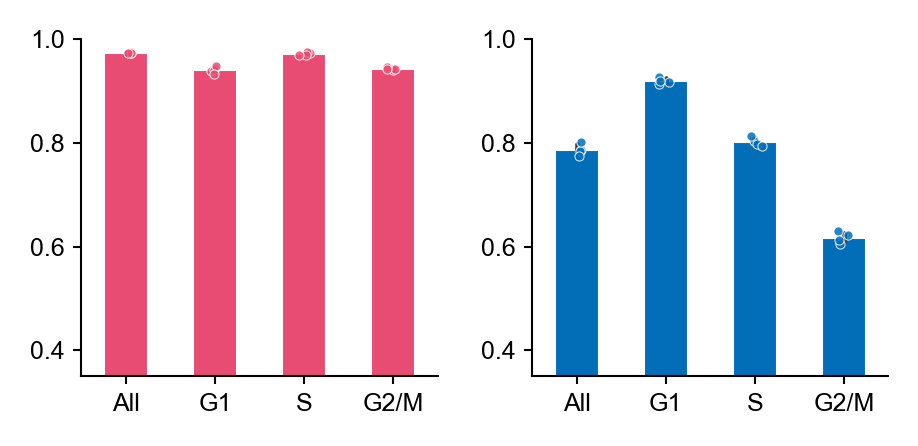

In [47]:
PHASE_ORIGIN = 'deepcycle'
INFER_METHOD = 'deeptx'
sub_data = data[(data['phase_origin']==PHASE_ORIGIN) & (data['infer_method']==INFER_METHOD)].drop(columns=['phase_origin','infer_method'])

data_non_cellcycle = pd.read_csv('extra/results/bs_bf_deeptx_indicators.csv')
data_non_cellcycle['phase'] = 'All'
data_non_cellcycle = data_non_cellcycle[data_non_cellcycle['eid']=='E116']

sub_data = pd.concat([sub_data, data_non_cellcycle], ignore_index=True)

sub_data['auc'] = sub_data['auc']/100
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(8/2.54, 4/2.54))
order = pd.Index(['All','G1','S','G2M',],name='marks')
xtick_labels = ['All','G1','S','G2/M',]
hue_order = pd.Index(["bf_label","bs_label"],name='target')

palette = ['#E94C72','#036EB8']


for idx, target in enumerate(targets):
    sns.barplot(data=sub_data[sub_data['target']==target],
                x='phase',
                y='auc',
                ax=ax[idx],order=order,
                color=palette[idx],width=0.5,alpha=1.0,saturation=1,linewidth=0.5
                )
    sns.stripplot(
        data=sub_data[sub_data['target']==target],
        x="phase",
        y="auc",
        order=order,
        color=palette[idx],
        dodge=True,
        jitter=0.08,
        size=2.2,
        alpha=0.85,
        linewidth=0.25,
        edgecolor="white",
        ax=ax[idx],
        legend=False,
    )
        # Show the plot
    ax[idx].set_ylabel("")
    ax[idx].set_xlabel("")
    ax[idx].set_ylim(ymin=0.35, ymax=1.0)
    ax[idx].legend().remove()
    ax[idx].set_xticklabels(xtick_labels,rotation=0,)

plt.tight_layout()  
plt.savefig(f"benchmarks/revised_v2/reviewer4/figures/cellcycle_model_performance_{PHASE_ORIGIN}_{INFER_METHOD}.pdf", format='pdf', bbox_inches='tight')
plt.show()

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/4123416321.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx].legend().remove()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/4123416321.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx].legend().remove()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78432/4123416321.py:138: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


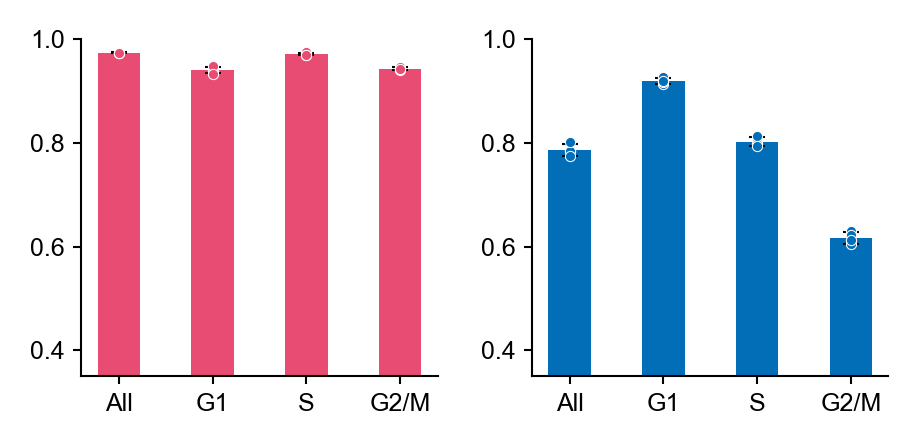

In [48]:
# =========================
# config
# =========================
PHASE_ORIGIN = 'deepcycle'
INFER_METHOD = 'deeptx'
targets = ['bf_label','bs_label']

# =========================
# data load
# =========================
# data = pd.read_csv('benchmarks/revised_v2/reviewer4/results/bs_bf_cellcycle_indicators.csv')

sub_data = data[
    (data['phase_origin'] == PHASE_ORIGIN) &
    (data['infer_method'] == INFER_METHOD)
].drop(columns=['phase_origin','infer_method'])

data_non_cellcycle = pd.read_csv('extra/results/bs_bf_deeptx_indicators.csv')
data_non_cellcycle['phase'] = 'All'
data_non_cellcycle = data_non_cellcycle[data_non_cellcycle['eid'] == 'E116']

sub_data = pd.concat([sub_data, data_non_cellcycle], ignore_index=True)
sub_data['auc'] = sub_data['auc'] / 100


# =========================
# plot setup
# =========================
fig, ax = plt.subplots(
    1, 2,
    constrained_layout=True,
    figsize=(8/2.54, 4/2.54)
)

order = ['All','G1','S','G2M']
xtick_labels = ['All','G1','S','G2/M']

x_base = np.arange(len(order))

# =========================================================
# GEOMETRY CONTROL (phase spacing system)
# =========================================================
hue_spacing = 0
bar_width = 0.45
offsets = np.linspace(-hue_spacing/2, hue_spacing/2, len(targets))

palette = {
    'bf_label': '#E94C72',
    'bs_label': '#036EB8'
}


# =========================================================
# MAIN LOOP
# =========================================================
for idx, target in enumerate(targets):

    df = sub_data[sub_data['target'] == target]

    summary = df.groupby(['phase'])['auc'].agg(['mean','std']).reset_index()

    # -------------------------
    # BAR + ERRORBAR
    # -------------------------
    means = np.array([summary[summary['phase'] == p]['mean'].values[0] for p in order])
    stds  = np.array([summary[summary['phase'] == p]['std'].values[0] for p in order])

    xpos = x_base + offsets[idx]

    ax[idx].bar(
        xpos,
        means,
        width=bar_width,
        color=palette[target],
        alpha=1.0,
        linewidth=0.0,
        edgecolor='none'
    )

    ax[idx].errorbar(
        xpos,
        means,
        yerr=stds,
        fmt='none',
        ecolor='black',
        elinewidth=0.5,
        capsize=2,
        capthick=0.5,
        zorder=2
    )

    # -------------------------
    # DOTPLOT (manual scatter)
    # -------------------------
    for p_idx, phase in enumerate(order):

        sub_raw = df[df['phase'] == phase]

        # jitter-free deterministic scatter
        x = np.full(len(sub_raw), x_base[p_idx]) + offsets[idx]

        ax[idx].scatter(
            x,
            sub_raw['auc'].values,
            s=6,
            color=palette[target],
            alpha=1.0,
            edgecolor="white",
            linewidth=0.25,
            zorder=3
        )

    # -------------------------
    # formatting
    # -------------------------
    ax[idx].set_ylabel("")
    ax[idx].set_xlabel("")
    ax[idx].set_ylim(0.35, 1.0)
    ax[idx].set_xticks(x_base)
    ax[idx].set_xticklabels(xtick_labels, rotation=0)

    ax[idx].legend().remove()


# =========================
# legend
# =========================
legend_patches = [
    mpatches.Patch(color='#E94C72', label='BF'),
    mpatches.Patch(color='#036EB8', label='BS'),
]

fig.legend(handles=legend_patches, loc='upper center', ncol=2, frameon=False).remove()

# =========================
# save
# =========================
plt.tight_layout()

plt.savefig(
    f"benchmarks/revised_v2/reviewer4/figures/cellcycle_model_performance_{PHASE_ORIGIN}_{INFER_METHOD}.pdf",
    format='pdf',
    bbox_inches='tight'
)

plt.show()